# 1.0 Imports

### 1.1 Libs

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import inflection
import warnings
warnings.filterwarnings('ignore')
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from statsmodels.base.model import GenericLikelihoodModel

### 1.2 Functions

In [5]:
def gauss(x, a, mu, sigma):
    return a * np.exp(-((x - mu)**2) / (2 * sigma**2))

def elasticity_gauss(P, mu, sigma):
    return -(P * (P - mu)) / (sigma**2)

### 1.3 Loading data

In [6]:
df_raw = pd.read_csv('../datasets/df_ready.csv', encoding='unicode_escape', low_memory=False)

In [3]:
df_raw.head().T

,0,1,2,3,4
Unnamed: 0,4,5,6,7,8
Date_imp,2017-12-14 06:00:00,2017-09-08 05:00:00,2017-10-24 04:00:00,2017-08-15 15:00:00,2017-09-14 21:00:00
Date_imp_d,2017/12/14,2017/09/08,2017/10/24,2017/08/15,2017/09/14
Cluster,35,35,35,35,35
Category_name,"speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth"
name,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...
price,69.0,69.0,66.0,74.99,69.99
disc_price,64.99,69.0,66.0,74.99,69.99
merchant,Walmart.com,Walmart.com,Walmart.com,Walmart.com,Walmart.com
condition,New,New,New,New,New


# 2.0 Descrição dos dados

In [7]:
df1 = df_raw.copy()

In [5]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23151 entries, 0 to 23150
Data columns (total 32 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       23151 non-null  int64  
 1   Date_imp         23151 non-null  object 
 2   Date_imp_d       23151 non-null  object 
 3   Cluster          23151 non-null  int64  
 4   Category_name    23151 non-null  object 
 5   name             23151 non-null  object 
 6   price            23151 non-null  float64
 7   disc_price       23151 non-null  float64
 8   merchant         23151 non-null  object 
 9   condition        23151 non-null  object 
 10  Disc_percentage  23151 non-null  float64
 11  isSale           23151 non-null  object 
 12  Imp_count        23151 non-null  int64  
 13  brand            23151 non-null  object 
 14  p_description    23151 non-null  object 
 15  currency         23151 non-null  object 
 16  dateAdded        23151 non-null  object 
 17  dateSeen    

### 2.1 Renomear colunas

In [8]:
cols_old = ['Unnamed: 0', 'Date_imp', 'Date_imp_d', 'Cluster', 'Category_name', 'name', 'price', 'disc_price', 
       'merchant', 'condition', 'Disc_percentage', 'isSale', 'Imp_count', 'brand', 'p_description',
       'currency', 'dateAdded', 'dateSeen', 'dateUpdated', 'imageURLs', 'manufacturer', 'shipping', 'sourceURLs', 
       'weight', 'Date_imp_d.1', 'Day_n', 'month', 'month_n', 'day', 'Week_Number', 'Zscore_1', 'price_std']

snakecase = lambda x: inflection.underscore(x)
cols_new = list(map(snakecase, cols_old))
df1.columns = cols_new

### 2.2 Check NA

In [7]:
df1.isna().sum()

unnamed: 0             0
date_imp               0
date_imp_d             0
cluster                0
category_name          0
name                   0
price                  0
disc_price             0
merchant               0
condition              0
disc_percentage        0
is_sale                0
imp_count              0
brand                  0
p_description          0
currency               0
date_added             0
date_seen              0
date_updated           0
image_ur_ls        22696
manufacturer       10639
shipping           11497
source_ur_ls        4930
weight                68
date_imp_d.1           0
day_n                  0
month                  0
month_n                0
day                    0
week_number            0
zscore_1             171
price_std              0
dtype: int64

### 2.3 Linhas duplicadas

In [9]:
linhas_duplicadas = df1[df1.duplicated(keep=False)].index
print("Linhas duplicadas:")
print(linhas_duplicadas)

Linhas duplicadas:
Index([], dtype='int64')


### 2.4 Change types

In [10]:
df1['date_imp'] = pd.to_datetime(df1['date_imp'])
df1['date_added'] = pd.to_datetime(df1['date_added'])
#df1['date_seen'] = pd.to_datetime(df1['date_seen'])
df1['date_updated'] = pd.to_datetime(df1['date_updated'])

### 2.5 Estatística Descritiva

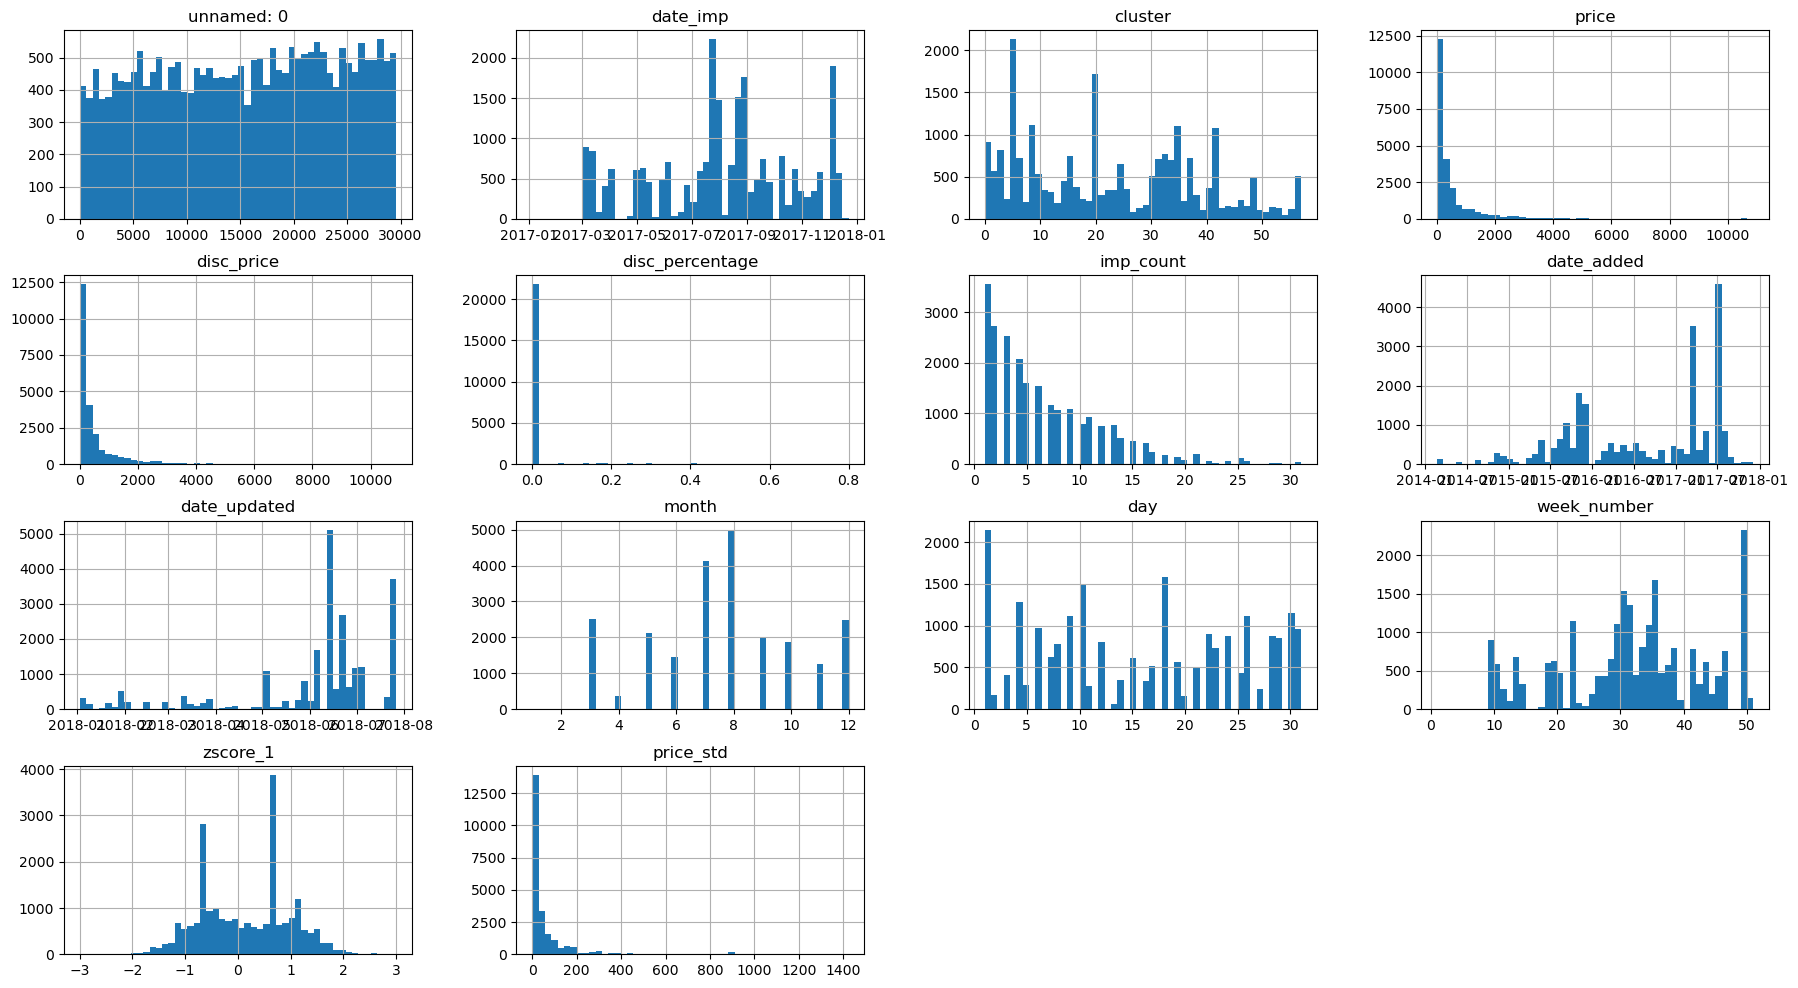

In [10]:
df1.hist(bins=50, figsize=(22,12));

In [11]:
num_attributes = df1.select_dtypes(include=['int64', 'float64'])
cat_attributes = df1.select_dtypes(exclude =['int64', 'float64', 'datetime64[ns]'])

### 2.5.1 Atributos numéricos

In [12]:
stat_desc = df1.describe().T
stat_desc

,count,mean,min,25%,50%,75%,max,std
unnamed: 0,23151.0,15338.318431,4.0,7897.5,15613.0,22678.0,29592.0,8528.805636
date_imp,23151,2017-08-05 09:49:29.444084224,2017-01-05 00:00:00,2017-06-09 15:00:00,2017-08-10 00:00:00,2017-09-24 07:00:00,2017-12-22 06:00:00,NaN
cluster,23151.0,22.682735,0.0,8.0,20.0,35.0,57.0,15.576818
price,23151.0,513.037803,1.0,82.99,199.99,540.0,10879.95,859.110002
disc_price,23151.0,494.104295,1.0,79.99,199.0,516.49,10879.95,808.588973
disc_percentage,23151.0,0.016933,0.0,0.0,0.0,0.0,0.8,0.077849
imp_count,23151.0,6.560926,1.0,2.0,5.0,10.0,31.0,5.403166
month,23151.0,7.65103,1.0,6.0,8.0,9.0,12.0,2.592843
day,23151.0,15.693879,1.0,7.0,16.0,24.0,31.0,9.681622
week_number,23151.0,31.34275,1.0,23.0,32.0,38.0,51.0,11.316498


### 2.5.2 Atributos categóricos

In [13]:
cat_attributes.apply(lambda x: x.unique().shape[0])

date_imp_d        188
category_name      58
name              908
merchant            7
condition           1
is_sale             2
brand             266
p_description     908
currency            1
date_added        872
date_seen        4373
date_updated      819
image_ur_ls         5
manufacturer      236
shipping           69
source_ur_ls     3923
weight            640
date_imp_d.1      188
day_n               7
month_n            11
dtype: int64

### 2.6 Comparação das colunas 'price' e 'disc_price'

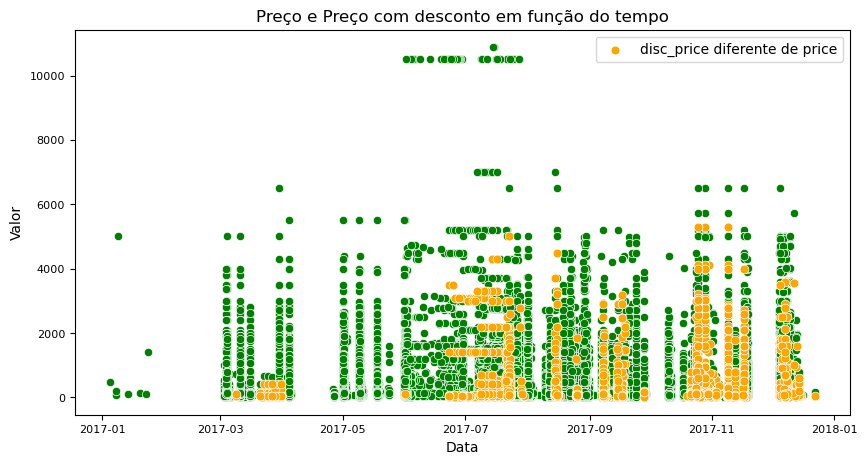

In [14]:
plt.figure(figsize=(10,5))

sns.scatterplot(data=df1, x='date_imp', y='price', color='green')
sns.scatterplot(data=df1[df1['price'] != df1['disc_price']], x='date_imp', y='disc_price',
    color='orange', s=40, marker='o', label='disc_price diferente de price')

plt.xlabel('Data')
plt.ylabel('Valor')
plt.title('Preço e Preço com desconto em função do tempo')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.legend()
plt.show()

### 2.7 Seleção de colunas

In [11]:
cols_drop = ['unnamed: 0', 'cluster', 'imp_count', 'zscore_1', 'price_std', 'date_imp_d', 'condition', 'is_sale',
            'currency', 'date_added', 'date_seen', 'date_updated', 'image_ur_ls', 'shipping', 'source_ur_ls', 
            'weight', 'date_imp_d.1']
df1 = df1.drop(cols_drop, axis=1)

In [16]:
df1.head().T

,0,1,2,3,4
date_imp,2017-12-14 06:00:00,2017-09-08 05:00:00,2017-10-24 04:00:00,2017-08-15 15:00:00,2017-09-14 21:00:00
category_name,"speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth"
name,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...
price,69.0,69.0,66.0,74.99,69.99
disc_price,64.99,69.0,66.0,74.99,69.99
merchant,Walmart.com,Walmart.com,Walmart.com,Walmart.com,Walmart.com
disc_percentage,0.06,0.0,0.0,0.0,0.0
brand,Boytone,Boytone,Boytone,Boytone,Boytone
p_description,"Stereos,Portable Bluetooth Speakers,TV, Video ...","Stereos,Portable Bluetooth Speakers,TV, Video ...","Stereos,Portable Bluetooth Speakers,TV, Video ...","Stereos,Portable Bluetooth Speakers,TV, Video ...","Stereos,Portable Bluetooth Speakers,TV, Video ..."
manufacturer,Boytone,Boytone,Boytone,Boytone,Boytone


# 3.0 Análise Exploratória dos Dados (EDA)

In [12]:
df2 = df1.copy()

### Quantidade de produtos vendidos por categoria

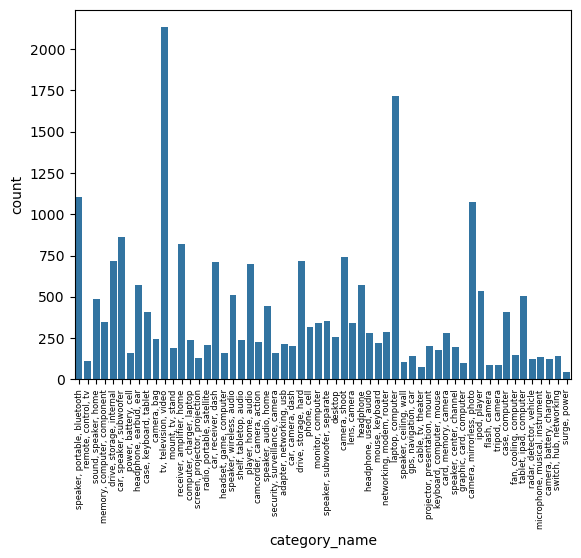

In [18]:
sns.countplot(data=df2, x='category_name');
plt.xticks(rotation=90)
plt.tick_params(axis='x', labelsize=6)
plt.show()

### Quantidade de produtos vendidos por marca para as categorias com maior número de vendas

In [19]:
aux = df2[df2['category_name'] == 'tv, television, video']
aux1 = df2[df2['category_name'] == 'laptop, computer']
aux2 = df2[df2['category_name'] == 'speaker, portable, bluetooth']

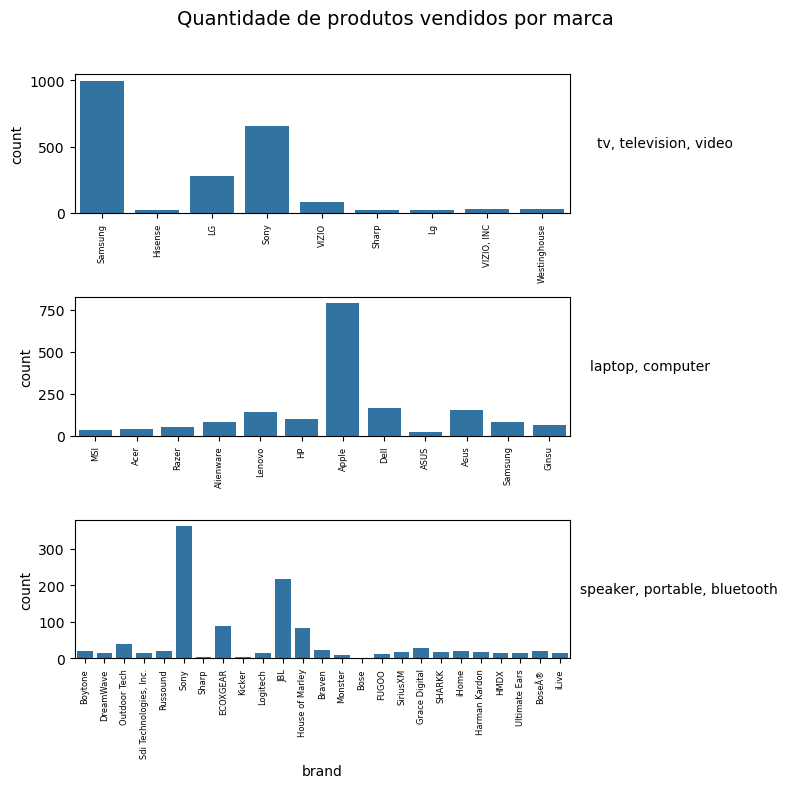

In [20]:
plt.figure(figsize=(8, 8))

plt.subplot(3, 1, 1)
sns.countplot(data=aux, x='brand')
plt.xticks(rotation=90, fontsize=6)
plt.xlabel("")
plt.title("")
xmax = plt.gca().get_xlim()[1]
plt.text(xmax + 0.5, plt.gca().get_ylim()[1]/2, "tv, television, video", va="center", ha="left", fontsize=10)  # Colocar texto da categoria ao lado, centralizado verticalmente

plt.subplot(3, 1, 2)
sns.countplot(data=aux1, x='brand')
plt.xticks(rotation=90, fontsize=6)
plt.xlabel("")
plt.title("")
xmax = plt.gca().get_xlim()[1]
plt.text(xmax + 0.5, plt.gca().get_ylim()[1]/2, "laptop, computer", va="center", ha="left", fontsize=10)

plt.subplot(3, 1, 3)
sns.countplot(data=aux2, x='brand')
plt.xticks(rotation=90, fontsize=6)
plt.xlabel("brand")
plt.title("")
xmax = plt.gca().get_xlim()[1]
plt.text(xmax + 0.5, plt.gca().get_ylim()[1]/2, "speaker, portable, bluetooth", va="center", ha="left", fontsize=10)

plt.suptitle("Quantidade de produtos vendidos por marca", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Quantidade de produtos vendidos por merchant para as categorias com maior número de vendas

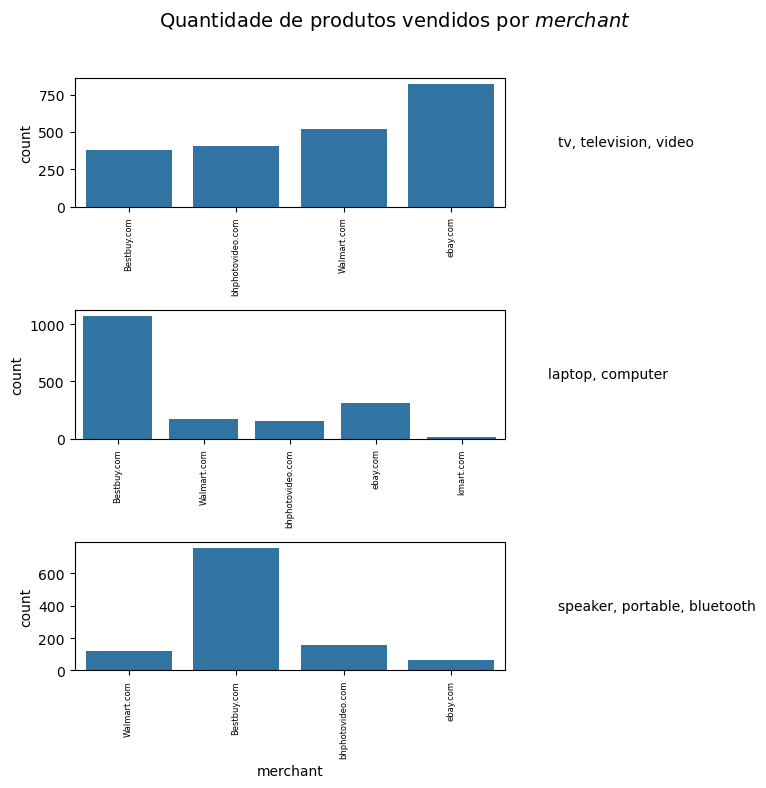

In [21]:
plt.figure(figsize=(8, 8))

plt.subplot(3, 1, 1)
sns.countplot(data=aux, x='merchant')
plt.xticks(rotation=90, fontsize=6)
plt.xlabel("")
plt.title("")
xmax = plt.gca().get_xlim()[1]
plt.text(xmax + 0.5, plt.gca().get_ylim()[1]/2, "tv, television, video", va="center", ha="left", fontsize=10)

plt.subplot(3, 1, 2)
sns.countplot(data=aux1, x='merchant')
plt.xticks(rotation=90, fontsize=6)
plt.xlabel("")
plt.title("")
xmax = plt.gca().get_xlim()[1]
plt.text(xmax + 0.5, plt.gca().get_ylim()[1]/2, "laptop, computer", va="center", ha="left", fontsize=10)

plt.subplot(3, 1, 3)
sns.countplot(data=aux2, x='merchant')
plt.xticks(rotation=90, fontsize=6)
plt.xlabel("merchant")
plt.title("")
xmax = plt.gca().get_xlim()[1]
plt.text(xmax + 0.5, plt.gca().get_ylim()[1]/2, "speaker, portable, bluetooth", va="center", ha="left", fontsize=10)

plt.suptitle("Quantidade de produtos vendidos por $\t{merchant}$", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Para a categoria $speaker, portable, bluetooth$

In [22]:
aux = df2[(df2['category_name'] == 'speaker, portable, bluetooth') & (df2['merchant'] == 'Bestbuy.com')]
aux.head().T

,6,7,8,9,10
date_imp,2017-10-10 05:00:00,2017-08-28 07:00:00,2017-08-12 09:00:00,2017-08-01 03:00:00,2017-07-26 15:00:00
category_name,"speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth"
name,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Boytone - 2500W 2.1-Ch. Home Theater System - ...
price,69.99,66.99,65.99,64.99,64.99
disc_price,69.99,66.99,65.99,64.99,64.99
merchant,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com
disc_percentage,0.0,0.0,0.0,0.0,0.0
brand,Boytone,Boytone,Boytone,Boytone,Boytone
p_description,"Stereos,Portable Bluetooth Speakers,TV, Video ...","Stereos,Portable Bluetooth Speakers,TV, Video ...","Stereos,Portable Bluetooth Speakers,TV, Video ...","Stereos,Portable Bluetooth Speakers,TV, Video ...","Stereos,Portable Bluetooth Speakers,TV, Video ..."
manufacturer,Boytone,Boytone,Boytone,Boytone,Boytone


In [23]:
# quantidade de cada produto dentro do categoria de laptop, computer
aux.groupby('name').count()

,date_imp,category_name,price,disc_price,merchant,disc_percentage,brand,p_description,manufacturer,day_n,month,month_n,day,week_number
name,,,,,,,,,,,,,,
BOOM 2 Wireless Bluetooth Speaker - Indigo,16,16,16,16,16,16,16,16,0,16,16,16,16,16
BRAVEN BRV-HD Wireless Bluetooth Speaker [28 Hour Playtime][Water Resistant] Built-In 8800 mAh Power Bank Charger - Black,4,4,4,4,4,4,4,4,4,4,4,4,4,4
BoseÂ® - SoundlinkÂ® Color Bluetooth Speaker II - Coral Red,21,21,21,21,21,21,21,21,21,21,21,21,21,21
Boytone - 2500W 2.1-Ch. Home Theater System - Black Diamond,15,15,15,15,15,15,15,15,15,15,15,15,15,15
Braven BRV-BLADE Wireless Portable Bluetooth Speaker [22 Hour Playtime][Waterproof] 4000 mAh Power Bank Charger - Black,4,4,4,4,4,4,4,4,0,4,4,4,4,4
Chant Mini Portable Bluetooth Wireless Speaker (Navy),15,15,15,15,15,15,15,15,15,15,15,15,15,15
Chant Sport BT Portable Audio System (Black),15,15,15,15,15,15,15,15,0,15,15,15,15,15
Details About Logitech Ue Roll 2 Wireless Portable Bluetooth Waterproof Speaker,8,8,8,8,8,8,8,8,8,8,8,8,8,8
"DreamWave - Tremor Portable Bluetooth Speaker - Green,Black",15,15,15,15,15,15,15,15,0,15,15,15,15,15


### Speaker, portable, bluetooth : estudo de JBL Clip2 Portable Speaker

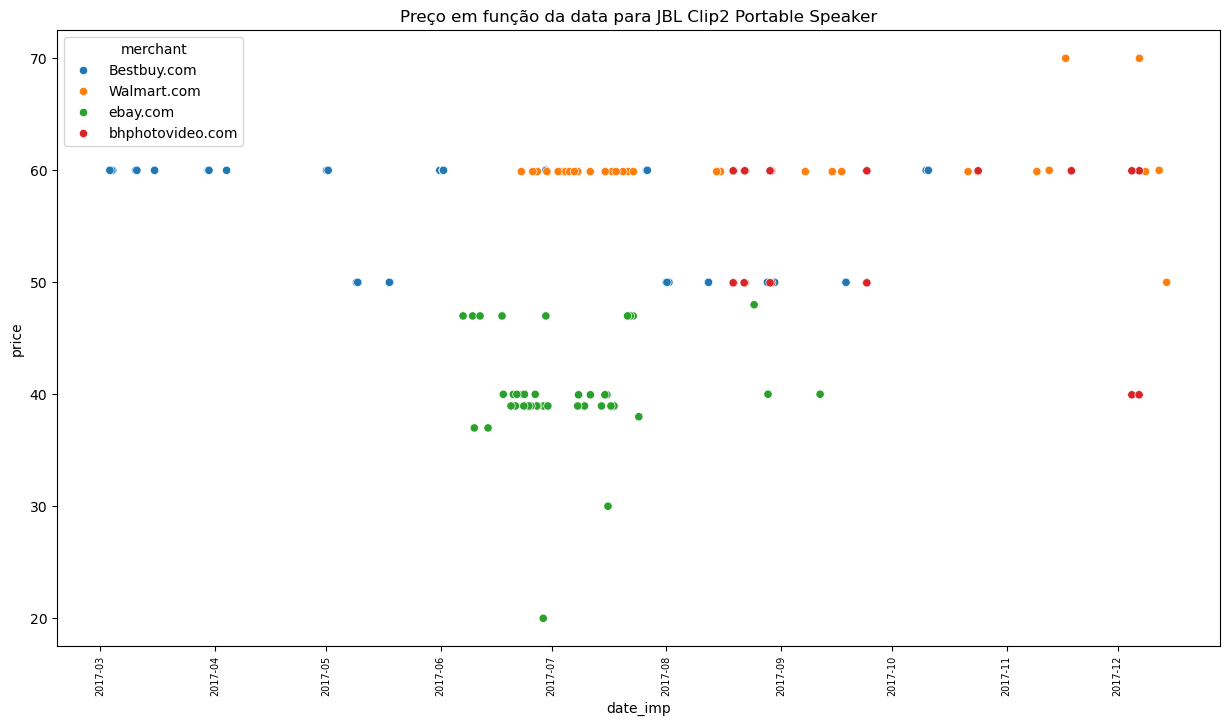

In [24]:
aux = df2[(df2['category_name'] == 'speaker, portable, bluetooth') & (df2['name'] == 'JBL Clip2 Portable Speaker')]

plt.figure(figsize=(15, 8))
sns.scatterplot(x='date_imp', y='price', data=aux, hue='merchant')
plt.xticks(rotation=90, fontsize=7)
plt.title('Preço em função da data para JBL Clip2 Portable Speaker')
plt.show;

### Merchant escolhido: Bestbuy.com

In [25]:
aux1 = df2[(df2['category_name'] == 'speaker, portable, bluetooth') & (df2['merchant'] == 'Bestbuy.com') & (df2['name'] == 'JBL Clip2 Portable Speaker')]
aux1.T

,19244,19245,19246,19247,19248,19249,19250,19251,19252,19253,...,19325,19326,19327,19328,19329,19330,19331,19332,19333,19334
date_imp,2017-09-18 14:00:00,2017-09-18 13:00:00,2017-08-30 07:00:00,2017-08-12 10:00:00,2017-08-01 00:00:00,2017-08-01 17:00:00,2017-05-09 15:00:00,2017-05-18 08:00:00,2017-05-18 04:00:00,2017-09-18 14:00:00,...,2017-07-26 21:00:00,2017-06-29 11:00:00,2017-06-01 17:00:00,2017-06-01 19:00:00,2017-05-01 15:00:00,2017-03-30 10:00:00,2017-03-10 22:00:00,2017-03-04 10:00:00,2017-03-04 03:00:00,2017-03-03 15:00:00
category_name,"speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth",...,"speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth","speaker, portable, bluetooth"
name,JBL Clip2 Portable Speaker,JBL Clip2 Portable Speaker,JBL Clip2 Portable Speaker,JBL Clip2 Portable Speaker,JBL Clip2 Portable Speaker,JBL Clip2 Portable Speaker,JBL Clip2 Portable Speaker,JBL Clip2 Portable Speaker,JBL Clip2 Portable Speaker,JBL Clip2 Portable Speaker,...,JBL Clip2 Portable Speaker,JBL Clip2 Portable Speaker,JBL Clip2 Portable Speaker,JBL Clip2 Portable Speaker,JBL Clip2 Portable Speaker,JBL Clip2 Portable Speaker,JBL Clip2 Portable Speaker,JBL Clip2 Portable Speaker,JBL Clip2 Portable Speaker,JBL Clip2 Portable Speaker
price,49.99,49.99,49.99,49.99,49.99,49.99,49.99,49.99,49.99,49.99,...,59.99,59.99,59.99,59.99,59.99,59.99,59.99,59.99,59.99,59.99
disc_price,49.99,49.99,49.99,49.99,49.99,49.99,49.99,49.99,49.99,49.99,...,59.99,59.99,59.99,59.99,59.99,59.99,59.99,59.99,59.99,59.99
merchant,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,...,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com,Bestbuy.com
disc_percentage,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
brand,JBL,JBL,JBL,JBL,JBL,JBL,JBL,JBL,JBL,JBL,...,JBL,JBL,JBL,JBL,JBL,JBL,JBL,JBL,JBL,JBL
p_description,"Stereos,Audio Docks & Mini Speakers,Speaker Sy...","Stereos,Audio Docks & Mini Speakers,Speaker Sy...","Stereos,Audio Docks & Mini Speakers,Speaker Sy...","Stereos,Audio Docks & Mini Speakers,Speaker Sy...","Stereos,Audio Docks & Mini Speakers,Speaker Sy...","Stereos,Audio Docks & Mini Speakers,Speaker Sy...","Stereos,Audio Docks & Mini Speakers,Speaker Sy...","Stereos,Audio Docks & Mini Speakers,Speaker Sy...","Stereos,Audio Docks & Mini Speakers,Speaker Sy...","Stereos,Audio Docks & Mini Speakers,Speaker Sy...",...,"Stereos,Audio Docks & Mini Speakers,Speaker Sy...","Stereos,Audio Docks & Mini Speakers,Speaker Sy...","Stereos,Audio Docks & Mini Speakers,Speaker Sy...","Stereos,Audio Docks & Mini Speakers,Speaker Sy...","Stereos,Audio Docks & Mini Speakers,Speaker Sy...","Stereos,Audio Docks & Mini Speakers,Speaker Sy...","Stereos,Audio Docks & Mini Speakers,Speaker Sy...","Stereos,Audio Docks & Mini Speakers,Speaker Sy...","Stereos,Audio Docks & Mini Speakers,Speaker Sy...","Stereos,Audio Docks & Mini Speakers,Speaker Sy..."
manufacturer,JBL,JBL,JBL,JBL,JBL,JBL,JBL,JBL,JBL,JBL,...,JBL,JBL,JBL,JBL,JBL,JBL,JBL,JBL,JBL,JBL


### Determinando a demanda (ou quantidade vendida)

In [26]:
# neste caso, a demanda é a quantidade de produtos vendidos em determinado preço

In [27]:
df_demanda= aux1.groupby('price')['name'].count().reset_index(name='quantidade')

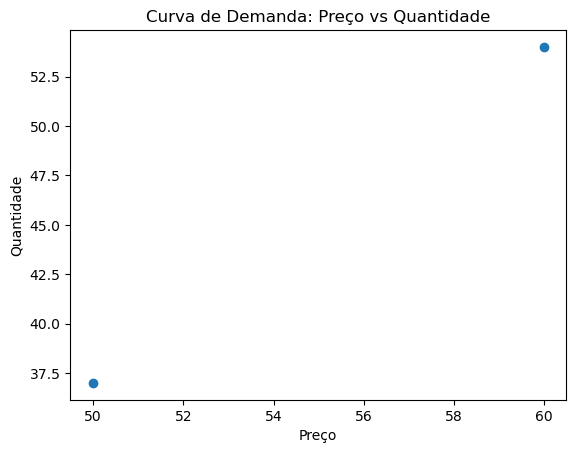

In [28]:
plt.scatter(df_demanda['price'], df_demanda['quantidade'])
plt.xlabel("Preço")
plt.ylabel("Quantidade")
plt.title("Curva de Demanda: Preço vs Quantidade")
plt.show()

### Determinando preço ótimo empírico

In [29]:
# Preço ótimo - preço que resulta na maior receita conforme a demanda observada
df_demanda['receita'] = df_demanda['price'] * df_demanda['quantidade']
print(df_demanda.loc[df_demanda['receita'].idxmax()])

price           59.99
quantidade      54.00
receita       3239.46
Name: 1, dtype: float64


In [30]:
df_demanda.T

,0,1
price,49.99,59.99
quantidade,37.00,54.00
receita,1849.63,3239.46


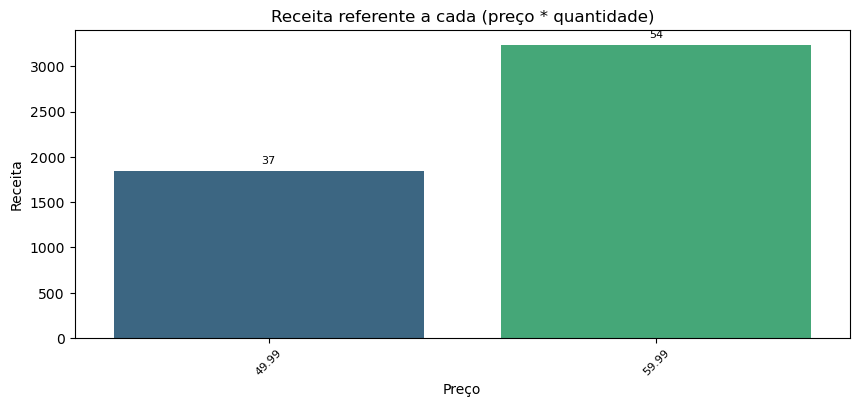

In [31]:
plt.figure(figsize=(10, 4))
ax = sns.barplot(x='price', y='receita', data=df_demanda, palette='viridis')
plt.xlabel('Preço')
plt.ylabel('Receita')
plt.xticks(rotation=45, fontsize=8)
plt.title('Receita referente a cada (preço * quantidade)')

for i, (receita, quantidade) in enumerate(zip(df_demanda['receita'], df_demanda['quantidade'])):
    ax.text(i, receita + 5, str(quantidade), ha='center', va='bottom', fontsize=8)  

plt.show()

### Determinando a elasticidade

In [32]:
# como a quantidade de agrupamentos de preços é muito pequeno, não é factível fazer ajustes com modelos
# linear e log-log. portanto, será calculada a elasticidade local à partir do preço ótimo empírico

In [33]:
# encontrar o preço ótimo (máxima receita)
idx_max = df_demanda['receita'].idxmax()
preco_otimo = df_demanda.loc[idx_max, 'price']
q_otimo = df_demanda.loc[idx_max, 'quantidade']

# pegar vizinhos (se existirem)
if idx_max > 0 and idx_max < len(df_demanda) - 1:
    preco_menor, q_menor = df_demanda.loc[idx_max - 1, ['price', 'quantidade']]
    preco_maior, q_maior = df_demanda.loc[idx_max + 1, ['price', 'quantidade']]

    delta_p = preco_maior - preco_menor
    delta_q = q_maior - q_menor

    # elasticidade em torno do preço ótimo
    E = (delta_q / q_otimo) / (delta_p / preco_otimo)

    print(f"Preço ótimo: {preco_otimo}, Quantidade: {q_otimo}")
    print(f"Elasticidade em torno de {preco_otimo}: {E:.2f}")
else:
    print("Não há vizinhos suficientes para calcular a elasticidade.")
    print("É necessário mais agrupamentos de preços para fazer esse cálculo.")

Não há vizinhos suficientes para calcular a elasticidade.
É necessário mais agrupamentos de preços para fazer esse cálculo.


### Merchant escolhido: Walmart.com

In [79]:
aux21 = df2[(df2['category_name'] == 'speaker, portable, bluetooth') & (df2['merchant'] == 'Walmart.com') & (df2['name'] == 'JBL Clip2 Portable Speaker')]

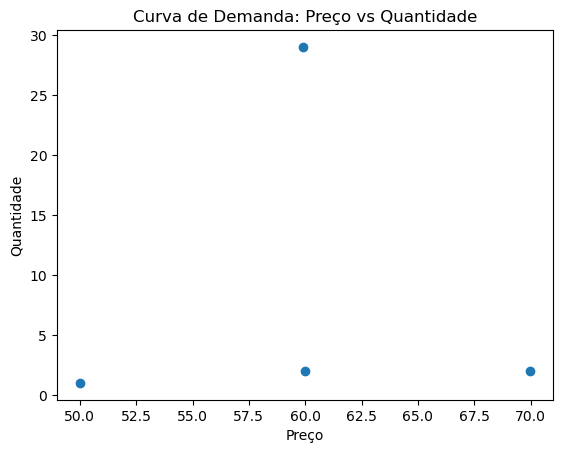

In [80]:
df_demanda= aux21.groupby('price')['name'].count().reset_index(name='quantidade')

plt.scatter(df_demanda['price'], df_demanda['quantidade'])
plt.xlabel("Preço")
plt.ylabel("Quantidade")
plt.title("Curva de Demanda: Preço vs Quantidade")
plt.show()

In [81]:
df_demanda['receita'] = df_demanda['price'] * df_demanda['quantidade']
print(df_demanda.loc[df_demanda['receita'].idxmax()])

price           59.88
quantidade      29.00
receita       1736.52
Name: 1, dtype: float64


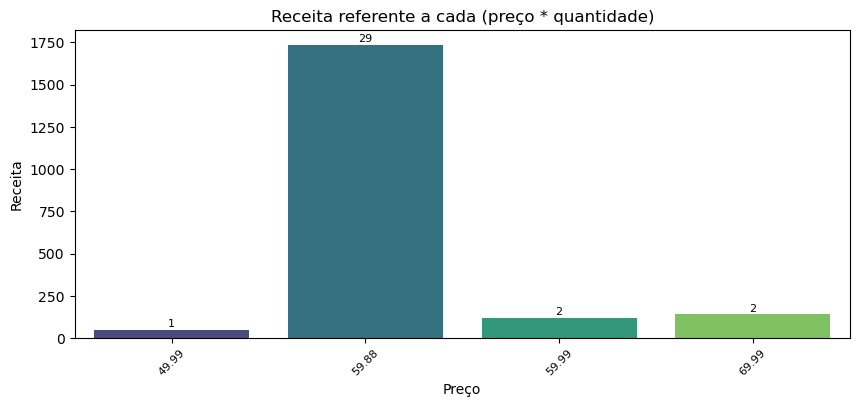

In [82]:
plt.figure(figsize=(10, 4))
ax = sns.barplot(x='price', y='receita', data=df_demanda, palette='viridis')
plt.xlabel('Preço')
plt.ylabel('Receita')
plt.xticks(rotation=45, fontsize=8)
plt.title('Receita referente a cada (preço * quantidade)')

for i, (receita, quantidade) in enumerate(zip(df_demanda['receita'], df_demanda['quantidade'])):
    ax.text(i, receita + 5, str(quantidade), ha='center', va='bottom', fontsize=8)  

plt.show()

In [83]:
# Modelo Linear: Q = a + B*P
X_lin = sm.add_constant(df_demanda['price'])
y_lin = df_demanda['quantidade']

model_lin = sm.OLS(y_lin, X_lin).fit()
print("\n=== Modelo Linear ===")
print(model_lin.summary())

# Modelo Log-Log: ln(Q) = a + B ln(P)
df_demanda = df_demanda[(df_demanda['quantidade'] > 0) & (df_demanda['price'] > 0)]  # garantir que não há log de zero/negativo
X_log = sm.add_constant(np.log(df_demanda['price']))
y_log = np.log(df_demanda['quantidade'])

model_log = sm.OLS(y_log, X_log).fit()
print("\n=== Modelo Log-Log ===")
print(model_log.summary())

# Coeficientes:
beta_lin = model_lin.params['price']
beta_log = model_log.params['price']

print("\nCoeficiente do modelo linear:", beta_lin)
print("Elasticidade no modelo linear (no preço médio):", beta_lin * (df_demanda['price'].mean() / df_demanda['quantidade'].mean()))
print("Elasticidade no modelo log-log:", beta_log)


=== Modelo Linear ===
                            OLS Regression Results                            
Dep. Variable:             quantidade   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.499
Method:                 Least Squares   F-statistic:                  0.001070
Date:                Sun, 21 Sep 2025   Prob (F-statistic):              0.977
Time:                        19:13:19   Log-Likelihood:                -15.562
No. Observations:                   4   AIC:                             35.12
Df Residuals:                       2   BIC:                             33.90
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.1781     71.

In [39]:
# como as métricas R-quadrado, p-valor e prob (F-statistic) não apresentaram valores dentro dos 
# parâmetros que adotamos como 'significativos', vamos fazer o ajuste não-linear usando a gaussiana

In [84]:
preco = df_demanda['price'].values
quantidade = df_demanda['quantidade'].values

# curve_fit
p0 = [quantidade.max(), np.median(preco), np.std(preco)]
popt, pcov = curve_fit(gauss, preco, quantidade, p0=p0, maxfev=10000)
a_cf, mu_cf, sigma_cf = popt
se_cf = np.sqrt(np.diag(pcov))

# statsmodels (GenericLikelihoodModel)
class GaussModel(GenericLikelihoodModel):
    def nloglikeobs(self, params):
        a, mu, sigma = params
        yhat = gauss(preco, a, mu, sigma)
        resid = quantidade - yhat
        sigma_res = np.std(resid)
        return 0.5 * np.log(2*np.pi) + np.log(sigma_res) + 0.5*(resid/sigma_res)**2

mod = GaussModel(quantidade)
mod.endog_index = preco
res = mod.fit(start_params=p0, method="bfgs", disp=False, maxiter=10000)
a_sm, mu_sm, sigma_sm = res.params

# elasticidade
df_demanda['elasticidade_curvefit'] = elasticity_gauss(df_demanda['price'], mu_cf, sigma_cf)
df_demanda['elasticidade_statsmodels'] = elasticity_gauss(df_demanda['price'], mu_sm, sigma_sm)

print("curve_fit params:", popt, "std err:", se_cf)
print(res.summary())

curve_fit params: [1.93629205e+02 5.96806948e+01 1.02277746e-01] std err: [2.57801086e+16 1.14855051e+13 2.30951759e+12]
                              GaussModel Results                              
Dep. Variable:                      y   Log-Likelihood:                -6.3100
Model:                     GaussModel   AIC:                             24.62
Method:            Maximum Likelihood   BIC:                             20.94
Date:                Sun, 21 Sep 2025                                         
Time:                        19:13:30                                         
No. Observations:                   4                                         
Df Residuals:                       1                                         
Df Model:                           3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
par0      

In [85]:
df_demanda

,price,quantidade,receita,elasticidade_curvefit,elasticidade_statsmodels
0,49.99,1,49.99,46310.104128,286026.341090
1,59.88,29,1736.52,-1140.874876,523.105063
2,59.99,2,119.98,-1773.796184,-3287.773072
3,69.99,2,139.98,-68976.807652,-408131.417397


In [ ]:
# apesar da regressão não linear gaussiana retornar resultados estatisticamente significativos,
# como os valores de elasticidades são muito altos, isso pode indicar poucos dados, quantidades muito 
# pequenas vendidas, modelo mal ajustado. baseando-se nisso, os dois ajustes não lineares não serão
# considerados para o cálculo da elasticidade.

In [86]:
# encontrar o preço ótimo (máxima receita)
idx_max = df_demanda['receita'].idxmax()
preco_otimo = df_demanda.loc[idx_max, 'price']
q_otimo = df_demanda.loc[idx_max, 'quantidade']

# pegar vizinhos (se existirem)
if idx_max > 0 and idx_max < len(df_demanda) - 1:
    preco_menor, q_menor = df_demanda.loc[idx_max - 1, ['price', 'quantidade']]
    preco_maior, q_maior = df_demanda.loc[idx_max + 1, ['price', 'quantidade']]

    delta_p = preco_maior - preco_menor
    delta_q = q_maior - q_menor

    # elasticidade em torno do preço ótimo
    E = (delta_q / q_otimo) / (delta_p / preco_otimo)

    print(f"Preço ótimo: {preco_otimo}, Quantidade: {q_otimo}")
    print(f"Elasticidade em torno de {preco_otimo}: {E:.2f}")
else:
    print("Não há vizinhos suficientes para calcular a elasticidade.")
    print("É necessário mais agrupamentos de preços para fazer esse cálculo.")

Preço ótimo: 59.88, Quantidade: 29
Elasticidade em torno de 59.88: 0.21


### Merchant escolhido: bhphotovideo.com

In [87]:
aux31 = df2[(df2['category_name'] == 'speaker, portable, bluetooth') & (df2['merchant'] == 'bhphotovideo.com') & (df2['name'] == 'JBL Clip2 Portable Speaker')]

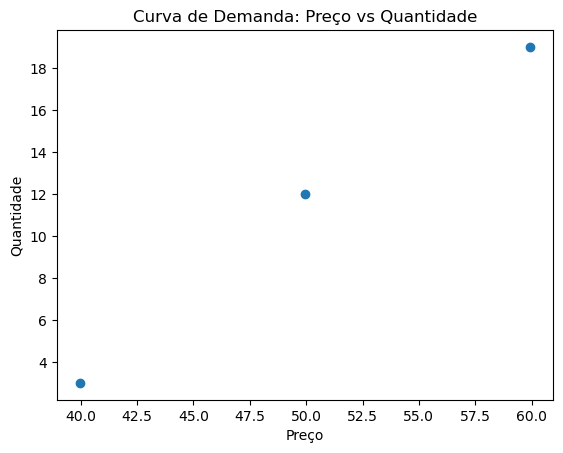

In [88]:
df_demanda= aux31.groupby('price')['name'].count().reset_index(name='quantidade')

plt.scatter(df_demanda['price'], df_demanda['quantidade'])
plt.xlabel("Preço")
plt.ylabel("Quantidade")
plt.title("Curva de Demanda: Preço vs Quantidade")
plt.show()

In [89]:
df_demanda['receita'] = df_demanda['price'] * df_demanda['quantidade']
print(df_demanda.loc[df_demanda['receita'].idxmax()])

price           59.95
quantidade      19.00
receita       1139.05
Name: 2, dtype: float64


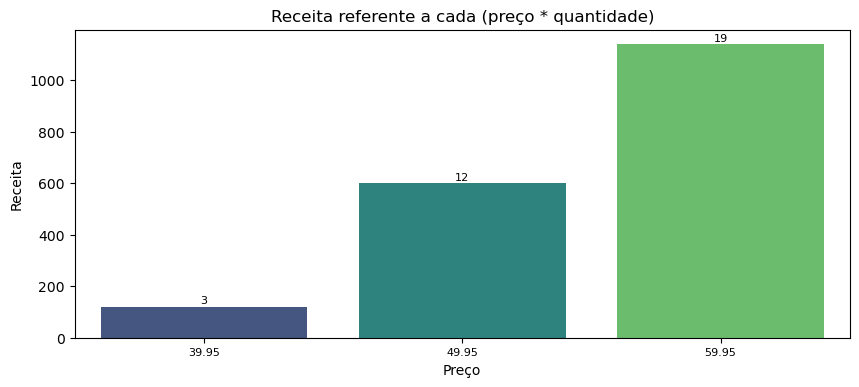

In [90]:
plt.figure(figsize=(10, 4))
ax = sns.barplot(x='price', y='receita', data=df_demanda, palette='viridis')
plt.xlabel('Preço')
plt.ylabel('Receita')
plt.xticks(rotation=0, fontsize=8)
plt.title('Receita referente a cada (preço * quantidade)')

for i, (receita, quantidade) in enumerate(zip(df_demanda['receita'], df_demanda['quantidade'])):
    ax.text(i, receita + 5, str(quantidade), ha='center', va='bottom', fontsize=8)  

plt.show()

In [91]:
# Modelo Linear: Q = a + B*P
X_lin = sm.add_constant(df_demanda['price'])
y_lin = df_demanda['quantidade']

model_lin = sm.OLS(y_lin, X_lin).fit()
print("\n=== Modelo Linear ===")
print(model_lin.summary())

# Modelo Log-Log: ln(Q) = a + B ln(P)
df_demanda = df_demanda[(df_demanda['quantidade'] > 0) & (df_demanda['price'] > 0)]  # garantir que não há log de zero/negativo
X_log = sm.add_constant(np.log(df_demanda['price']))
y_log = np.log(df_demanda['quantidade'])

model_log = sm.OLS(y_log, X_log).fit()
print("\n=== Modelo Log-Log ===")
print(model_log.summary())

# Coeficientes:
beta_lin = model_lin.params['price']
beta_log = model_log.params['price']

print("\nCoeficiente do modelo linear:", beta_lin)
print("Elasticidade no modelo linear (no preço médio):", beta_lin * (df_demanda['price'].mean() / df_demanda['quantidade'].mean()))
print("Elasticidade no modelo log-log:", beta_log)


=== Modelo Linear ===
                            OLS Regression Results                            
Dep. Variable:             quantidade   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                     192.0
Date:                Sun, 21 Sep 2025   Prob (F-statistic):             0.0459
Time:                        19:14:05   Log-Likelihood:                -2.0007
No. Observations:                   3   AIC:                             8.001
Df Residuals:                       1   BIC:                             6.199
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -28.6267      2.

In [92]:
# curva resposta
alpha = model_lin.params['const']
beta = model_lin.params['price']

preco_otimo = 59.95  
variacoes = [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]  # -30%, -20%, -10%, preço ótimo, +10%, +20%, +30%

for v in variacoes:
    P = preco_otimo * v
    Q = alpha + beta * P
    E = beta * (P / Q)
    print(f"Preço: {P:.2f}, Quantidade: {Q:.2f}, Elasticidade: {E:.3f}")

Preço: 41.96, Quantidade: 4.95, Elasticidade: 6.789
Preço: 47.96, Quantidade: 9.74, Elasticidade: 3.939
Preço: 53.96, Quantidade: 14.54, Elasticidade: 2.969
Preço: 59.95, Quantidade: 19.33, Elasticidade: 2.481
Preço: 65.95, Quantidade: 24.13, Elasticidade: 2.186
Preço: 71.94, Quantidade: 28.93, Elasticidade: 1.990
Preço: 77.94, Quantidade: 33.72, Elasticidade: 1.849


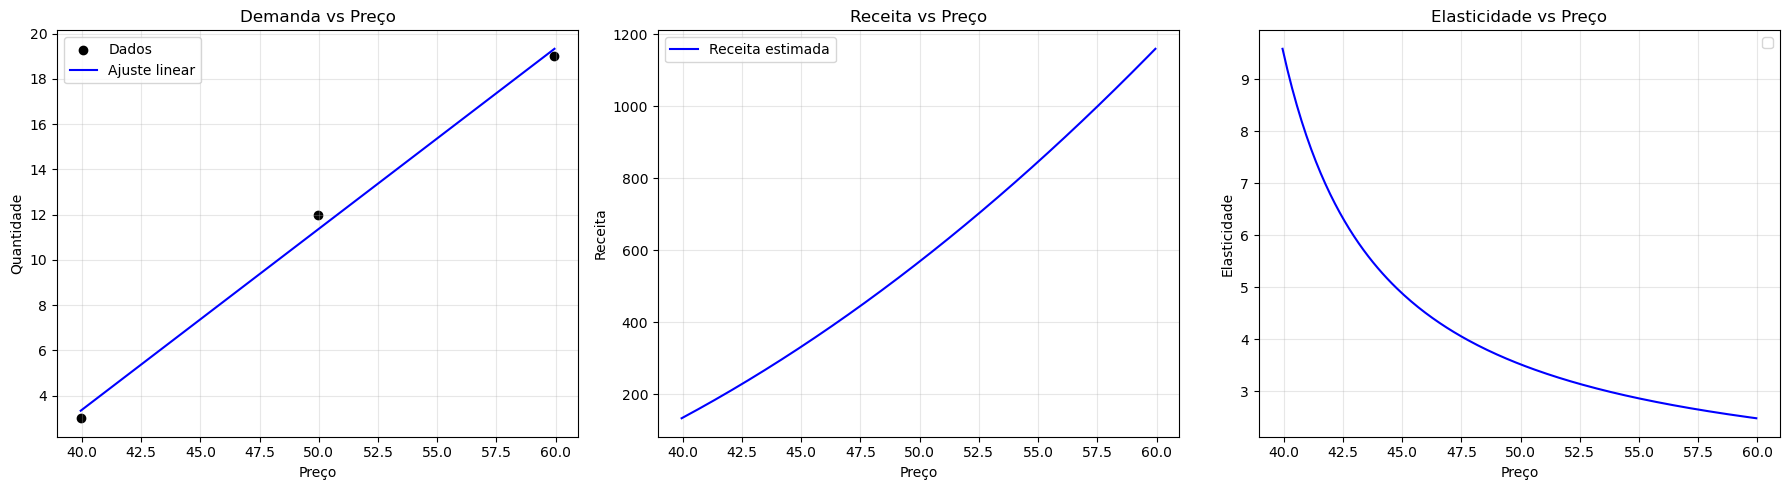

In [96]:
X = sm.add_constant(df_demanda['price'])
y = df_demanda["quantidade"]
model = sm.OLS(y, X).fit()

# coeficientes da regressão
beta0, beta1 = model.params

precos = np.linspace(df_demanda['price'].min(), df_demanda['price'].max(), 200)
quantidades_pred = beta0 + beta1 * precos
receita = precos * quantidades_pred
elasticidade = beta1 * (precos / quantidades_pred)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Demanda
axes[0].scatter(df_demanda['price'], df_demanda["quantidade"], label="Dados", color="black")
axes[0].plot(precos, quantidades_pred, color="blue", label="Ajuste linear")
axes[0].set_title("Demanda vs Preço")
axes[0].set_xlabel("Preço")
axes[0].set_ylabel("Quantidade")
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Receita
axes[1].plot(precos, receita, color="blue", label="Receita estimada")
axes[1].set_title("Receita vs Preço")
axes[1].set_xlabel("Preço")
axes[1].set_ylabel("Receita")
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Elasticidade
axes[2].plot(precos, elasticidade, color="blue")
axes[2].set_title("Elasticidade vs Preço")
axes[2].set_xlabel("Preço")
axes[2].set_ylabel("Elasticidade")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Merchant escolhido: ebay.com

In [97]:
aux41 = df2[(df2['category_name'] == 'speaker, portable, bluetooth') & (df2['merchant'] == 'ebay.com') & (df2['name'] == 'JBL Clip2 Portable Speaker')]

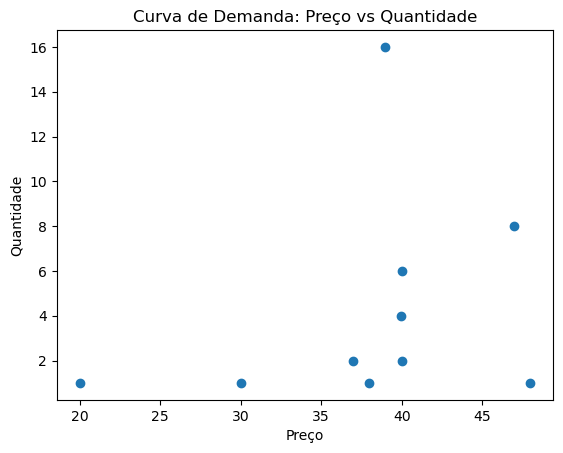

In [98]:
df_demanda= aux41.groupby('price')['name'].count().reset_index(name='quantidade')

plt.scatter(df_demanda['price'], df_demanda['quantidade'])
plt.xlabel("Preço")
plt.ylabel("Quantidade")
plt.title("Curva de Demanda: Preço vs Quantidade")
plt.show()

In [99]:
df_demanda['receita'] = df_demanda['price'] * df_demanda['quantidade']
print(df_demanda.loc[df_demanda['receita'].idxmax()])

price          38.95
quantidade     16.00
receita       623.20
Name: 4, dtype: float64


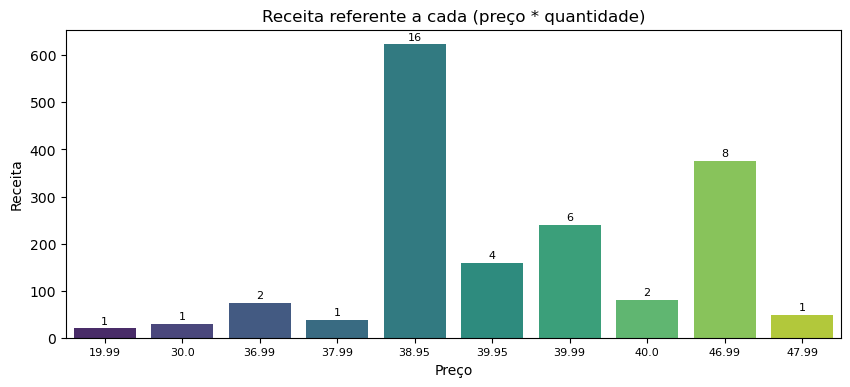

In [100]:
plt.figure(figsize=(10, 4))
ax = sns.barplot(x='price', y='receita', data=df_demanda, palette='viridis')
plt.xlabel('Preço')
plt.ylabel('Receita')
plt.xticks(rotation=0, fontsize=8)
plt.title('Receita referente a cada (preço * quantidade)')

for i, (receita, quantidade) in enumerate(zip(df_demanda['receita'], df_demanda['quantidade'])):
    ax.text(i, receita + 5, str(quantidade), ha='center', va='bottom', fontsize=8)  

plt.show()

In [101]:
# Modelo Linear: Q = a + B*P
X_lin = sm.add_constant(df_demanda['price'])
y_lin = df_demanda['quantidade']

model_lin = sm.OLS(y_lin, X_lin).fit()
print("\n=== Modelo Linear ===")
print(model_lin.summary())

# Modelo Log-Log: ln(Q) = a + B ln(P)
df_demanda = df_demanda[(df_demanda['quantidade'] > 0) & (df_demanda['price'] > 0)]  # garantir que não há log de zero/negativo
X_log = sm.add_constant(np.log(df_demanda['price']))
y_log = np.log(df_demanda['quantidade'])

model_log = sm.OLS(y_log, X_log).fit()
print("\n=== Modelo Log-Log ===")
print(model_log.summary())

# Coeficientes:
beta_lin = model_lin.params['price']
beta_log = model_log.params['price']

print("\nCoeficiente do modelo linear:", beta_lin)
print("Elasticidade no modelo linear (no preço médio):", beta_lin * (df_demanda['price'].mean() / df_demanda['quantidade'].mean()))
print("Elasticidade no modelo log-log:", beta_log)


=== Modelo Linear ===
                            OLS Regression Results                            
Dep. Variable:             quantidade   R-squared:                       0.079
Model:                            OLS   Adj. R-squared:                 -0.036
Method:                 Least Squares   F-statistic:                    0.6853
Date:                Mon, 22 Sep 2025   Prob (F-statistic):              0.432
Time:                        01:15:16   Log-Likelihood:                -28.944
No. Observations:                  10   AIC:                             61.89
Df Residuals:                       8   BIC:                             62.49
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1526      7.

In [102]:
preco = df_demanda['price'].values
quantidade = df_demanda['quantidade'].values

# curve_fit
p0 = [quantidade.max(), np.median(preco), np.std(preco)]
popt, pcov = curve_fit(gauss, preco, quantidade, p0=p0, maxfev=10000)
a_cf, mu_cf, sigma_cf = popt
se_cf = np.sqrt(np.diag(pcov))

# statsmodels (GenericLikelihoodModel)
class GaussModel(GenericLikelihoodModel):
    def nloglikeobs(self, params):
        a, mu, sigma = params
        yhat = gauss(preco, a, mu, sigma)
        resid = quantidade - yhat
        sigma_res = np.std(resid)
        return 0.5 * np.log(2*np.pi) + np.log(sigma_res) + 0.5*(resid/sigma_res)**2

mod = GaussModel(quantidade)
mod.endog_index = preco
res = mod.fit(start_params=p0, method="bfgs", disp=False, maxiter=10000)
a_sm, mu_sm, sigma_sm = res.params

# elasticidade
df_demanda['elasticidade_curvefit'] = elasticity_gauss(df_demanda['price'], mu_cf, sigma_cf)
df_demanda['elasticidade_statsmodels'] = elasticity_gauss(df_demanda['price'], mu_sm, sigma_sm)

print("curve_fit params:", popt, "std err:", se_cf)
print(res.summary())

curve_fit params: [ 7.47063504 42.75346911  4.58486079] std err: [5.62455879 2.28066243 4.14200122]
                              GaussModel Results                              
Dep. Variable:                      y   Log-Likelihood:                -28.369
Model:                     GaussModel   AIC:                             68.74
Method:            Maximum Likelihood   BIC:                             70.55
Date:                Mon, 22 Sep 2025                                         
Time:                        01:15:44                                         
No. Observations:                  10                                         
Df Residuals:                       7                                         
Df Model:                           3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
par0           7.4707      4.49

In [103]:
df_demanda

,price,quantidade,receita,elasticidade_curvefit,elasticidade_statsmodels
0,19.99,1,19.99,21.647061,21.645673
1,30.00,1,30.00,18.201085,18.199929
2,36.99,2,73.98,10.141822,10.141194
3,37.99,1,37.99,8.608755,8.608227
4,38.95,16,623.20,7.047499,7.047073
5,39.95,4,159.80,5.327951,5.327638
6,39.99,6,239.94,5.257190,5.256881
7,40.00,2,80.00,5.239476,5.239168
8,46.99,8,375.92,-9.470295,-9.469644
9,47.99,1,47.99,-11.954794,-11.953981


### Merchant escolhido: Bestbuy.com, Walmart.com, bhphotovideo.com, ebay.com

In [13]:
aux51 = df2[(df2['category_name'] == 'speaker, portable, bluetooth') & (df2['name'] == 'JBL Clip2 Portable Speaker')]

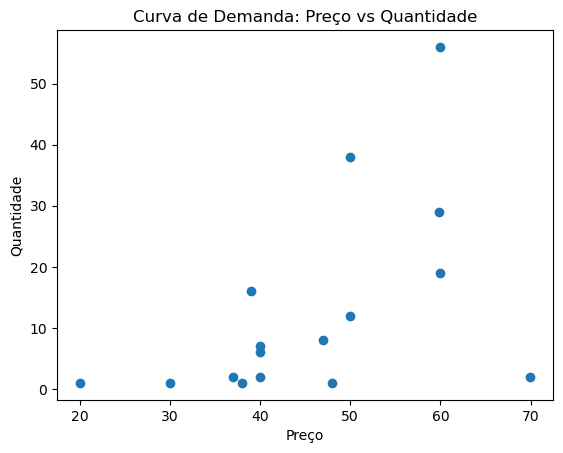

In [14]:
df_demanda= aux51.groupby('price')['name'].count().reset_index(name='quantidade')

plt.scatter(df_demanda['price'], df_demanda['quantidade'])
plt.xlabel("Preço")
plt.ylabel("Quantidade")
plt.title("Curva de Demanda: Preço vs Quantidade")
plt.show()

In [15]:
df_demanda['receita'] = df_demanda['price'] * df_demanda['quantidade']
print(df_demanda.loc[df_demanda['receita'].idxmax()])

price           59.99
quantidade      56.00
receita       3359.44
Name: 14, dtype: float64


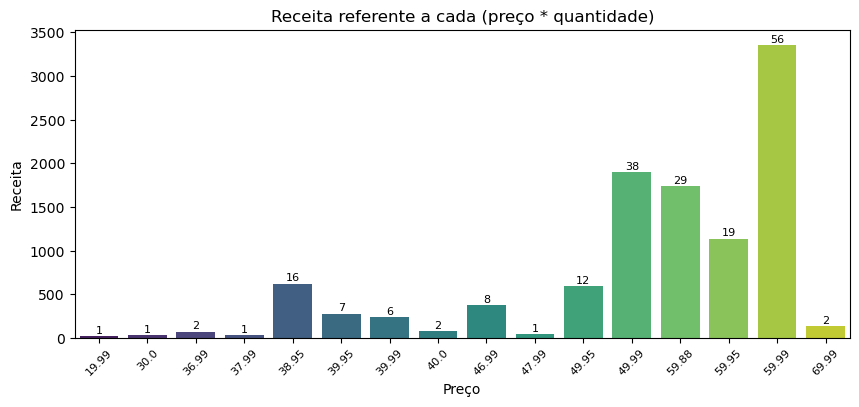

In [16]:
plt.figure(figsize=(10, 4))
ax = sns.barplot(x='price', y='receita', data=df_demanda, palette='viridis')
plt.xlabel('Preço')
plt.ylabel('Receita')
plt.xticks(rotation=45, fontsize=8)
plt.title('Receita referente a cada (preço * quantidade)')

for i, (receita, quantidade) in enumerate(zip(df_demanda['receita'], df_demanda['quantidade'])):
    ax.text(i, receita + 5, str(quantidade), ha='center', va='bottom', fontsize=8)  

plt.show()

In [17]:
# Modelo Linear: Q = a + B*P
X_lin = sm.add_constant(df_demanda['price'])
y_lin = df_demanda['quantidade']

model_lin = sm.OLS(y_lin, X_lin).fit()
print("\n=== Modelo Linear ===")
print(model_lin.summary())

# Modelo Log-Log: ln(Q) = a + B ln(P)
df_demanda = df_demanda[(df_demanda['quantidade'] > 0) & (df_demanda['price'] > 0)]  # garantir que não há log de zero/negativo
X_log = sm.add_constant(np.log(df_demanda['price']))
y_log = np.log(df_demanda['quantidade'])

model_log = sm.OLS(y_log, X_log).fit()
print("\n=== Modelo Log-Log ===")
print(model_log.summary())

# Coeficientes:
beta_lin = model_lin.params['price']
beta_log = model_log.params['price']

print("\nCoeficiente do modelo linear:", beta_lin)
print("Elasticidade no modelo linear (no preço médio):", beta_lin * (df_demanda['price'].mean() / df_demanda['quantidade'].mean()))
print("Elasticidade no modelo log-log:", beta_log)


=== Modelo Linear ===
                            OLS Regression Results                            
Dep. Variable:             quantidade   R-squared:                       0.252
Model:                            OLS   Adj. R-squared:                  0.199
Method:                 Least Squares   F-statistic:                     4.722
Date:                Mon, 22 Sep 2025   Prob (F-statistic):             0.0474
Time:                        18:59:08   Log-Likelihood:                -64.185
No. Observations:                  16   AIC:                             132.4
Df Residuals:                      14   BIC:                             133.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -16.1302     13.

In [18]:
# curva resposta - Modelo log-log
alpha = model_log.params['const']
beta = model_log.params['price']

preco_otimo = 59.99  
variacoes = [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]  

for v in variacoes:
    P = preco_otimo * v
    Q = np.exp(alpha) * (P ** beta)  # previsão no modelo log-log
    E = beta  # elasticidade constante
    print(f"Preço: {P:.2f}, Quantidade: {Q:.2f}, Elasticidade: {E:.3f}")

Preço: 41.99, Quantidade: 4.90, Elasticidade: 2.644
Preço: 47.99, Quantidade: 6.97, Elasticidade: 2.644
Preço: 53.99, Quantidade: 9.52, Elasticidade: 2.644
Preço: 59.99, Quantidade: 12.58, Elasticidade: 2.644
Preço: 65.99, Quantidade: 16.19, Elasticidade: 2.644
Preço: 71.99, Quantidade: 20.37, Elasticidade: 2.644
Preço: 77.99, Quantidade: 25.18, Elasticidade: 2.644


In [19]:
# assumindo df com 'preco' e 'quantidade'
preco = df_demanda['price'].values
quantidade = df_demanda['quantidade'].values

# curve_fit
p0 = [quantidade.max(), np.median(preco), np.std(preco)]
popt, pcov = curve_fit(gauss, preco, quantidade, p0=p0, maxfev=10000)
a_cf, mu_cf, sigma_cf = popt
se_cf = np.sqrt(np.diag(pcov))

# statsmodels (GenericLikelihoodModel)
class GaussModel(GenericLikelihoodModel):
    def nloglikeobs(self, params):
        a, mu, sigma = params
        yhat = gauss(preco, a, mu, sigma)
        resid = quantidade - yhat
        sigma_res = np.std(resid)
        return 0.5 * np.log(2*np.pi) + np.log(sigma_res) + 0.5*(resid/sigma_res)**2

mod = GaussModel(quantidade)
mod.endog_index = preco
res = mod.fit(start_params=p0, method="bfgs", disp=False, maxiter=10000)
a_sm, mu_sm, sigma_sm = res.params

# Elasticidades
df_demanda['elasticidade_curvefit'] = elasticity_gauss(df_demanda['price'], mu_cf, sigma_cf)
df_demanda['elasticidade_statsmodels'] = elasticity_gauss(df_demanda['price'], mu_sm, sigma_sm)

# Impressões rápidas
print("curve_fit params:", popt, "std err:", se_cf)
print(res.summary())

curve_fit params: [105.03328544  55.29096507   3.11699736] std err: [149.03340056   0.55919476   1.68507109]
                              GaussModel Results                              
Dep. Variable:                      y   Log-Likelihood:                -59.119
Model:                     GaussModel   AIC:                             130.2
Method:            Maximum Likelihood   BIC:                             134.9
Date:                Mon, 22 Sep 2025                                         
Time:                        19:00:24                                         
No. Observations:                  16                                         
Df Residuals:                      13                                         
Df Model:                           3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
par0         103.3627 

In [20]:
df_demanda

,price,quantidade,receita,elasticidade_curvefit,elasticidade_statsmodels
0,19.99,1,19.99,72.631749,71.428185
1,30.00,1,30.00,78.093302,76.803023
2,36.99,2,73.98,69.676360,68.529699
3,37.99,1,37.99,67.649837,66.537450
4,38.95,16,623.20,65.510708,64.434458
5,39.95,7,279.65,63.080713,62.045473
6,39.99,6,239.94,62.979232,61.945703
7,40.00,2,80.00,62.953810,61.920710
8,46.99,8,375.92,40.147745,39.498466
9,47.99,1,47.99,36.062693,35.482051


In [67]:
# análise não linear gaussiana não se aplica para esse conjunto de dados. para maxfev >= 90000, o programa roda 
# mas gera valores extremamente altos para os coeficientes (não condizentes com o problema em questão) e
# erros ainda maiores que os coeficientes. os valores de elasticidades também estão fora da faixa de valores
# 'aceitáveis'

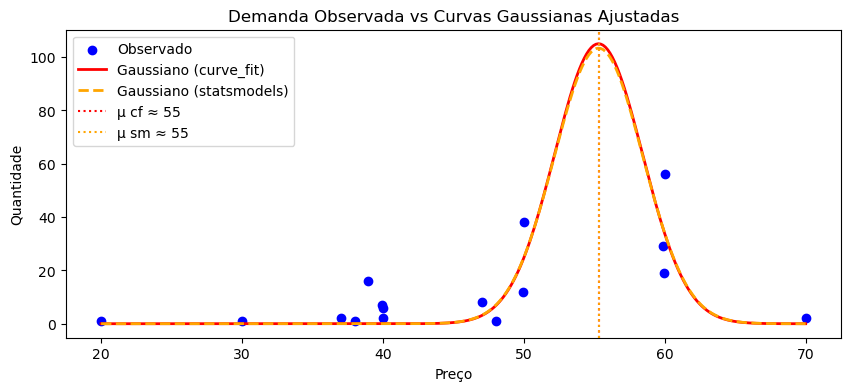

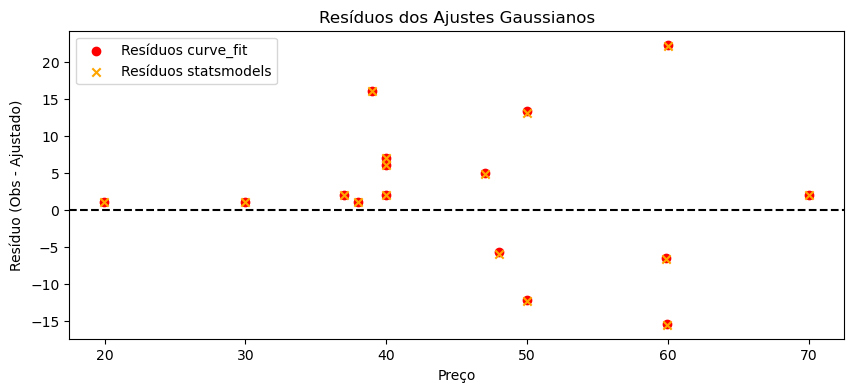

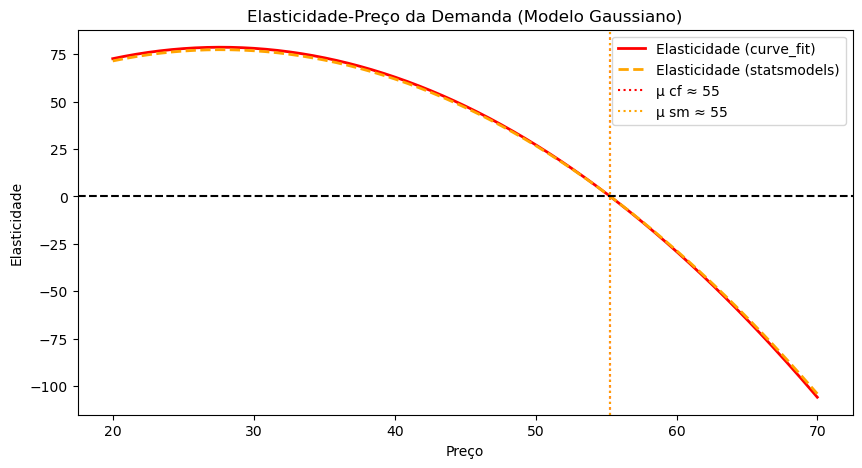

In [21]:
# Parâmetros estimados
a_cf, mu_cf, sigma_cf = popt  # do curve_fit
a_sm, mu_sm, sigma_sm = res.params  # do statsmodels

# Grid de preços para curvas suaves
preco_grid = np.linspace(df_demanda['price'].min(), df_demanda['price'].max(), 300)

# Previsões
q_pred_cf = gauss(preco_grid, a_cf, mu_cf, sigma_cf)
q_pred_sm = gauss(preco_grid, a_sm, mu_sm, sigma_sm)

# 1. Curva ajustada vs dados
plt.figure(figsize=(10,4))
plt.scatter(df_demanda['price'], df_demanda['quantidade'], color="blue", label="Observado")
plt.plot(preco_grid, q_pred_cf, color="red", linewidth=2, label="Gaussiano (curve_fit)")
plt.plot(preco_grid, q_pred_sm, color="orange", linestyle="--", linewidth=2, label="Gaussiano (statsmodels)")
plt.axvline(mu_cf, color="red", linestyle=":", label=f"μ cf ≈ {mu_cf:.0f}")
plt.axvline(mu_sm, color="orange", linestyle=":", label=f"μ sm ≈ {mu_sm:.0f}")
plt.title("Demanda Observada vs Curvas Gaussianas Ajustadas")
plt.xlabel("Preço")
plt.ylabel("Quantidade")
plt.legend()
plt.show()

# 2. Resíduos
q_fit_cf = gauss(df_demanda['price'], a_cf, mu_cf, sigma_cf)
q_fit_sm = gauss(df_demanda['price'], a_sm, mu_sm, sigma_sm)
residuos_cf = df_demanda['quantidade'] - q_fit_cf
residuos_sm = df_demanda['quantidade'] - q_fit_sm

plt.figure(figsize=(10,4))
plt.axhline(0, color="black", linestyle="--")
plt.scatter(df_demanda['price'], residuos_cf, color="red", label="Resíduos curve_fit")
plt.scatter(df_demanda['price'], residuos_sm, color="orange", marker="x", label="Resíduos statsmodels")
plt.title("Resíduos dos Ajustes Gaussianos")
plt.xlabel("Preço")
plt.ylabel("Resíduo (Obs - Ajustado)")
plt.legend()
plt.show()

# 3. Elasticidade vs preço
elasticidade_cf = elasticity_gauss(preco_grid, mu_cf, sigma_cf)
elasticidade_sm = elasticity_gauss(preco_grid, mu_sm, sigma_sm)

plt.figure(figsize=(10,5))
plt.plot(preco_grid, elasticidade_cf, color="red", linewidth=2, label="Elasticidade (curve_fit)")
plt.plot(preco_grid, elasticidade_sm, color="orange", linestyle="--", linewidth=2, label="Elasticidade (statsmodels)")
plt.axhline(0, color="black", linestyle="--")
plt.axvline(mu_cf, color="red", linestyle=":", label=f"μ cf ≈ {mu_cf:.0f}")
plt.axvline(mu_sm, color="orange", linestyle=":", label=f"μ sm ≈ {mu_sm:.0f}")
plt.title("Elasticidade-Preço da Demanda (Modelo Gaussiano)")
plt.xlabel("Preço")
plt.ylabel("Elasticidade")
plt.legend()
plt.show()

In [ ]:
# fazendo bins de preço para tentar melhorar o ajuste

In [23]:
grupo = 0
grupos = [grupo]

for i in range(1, len(df_demanda)):
    if (df_demanda.loc[i, 'price'] - df_demanda.loc[i-1, 'price']) > 0.50:
        grupo += 1  # inicia um novo grupo
    grupos.append(grupo)

df_demanda['grupo'] = grupos
df_demanda['receita'] = df_demanda['price'] * df_demanda['quantidade']

df_bin = df_demanda.groupby('grupo').agg(
    preco_min=('price', "min"),
    preco_max=('price', "max"),
    preco_medio=('price', 'mean'),
    quantidade_soma=('quantidade', 'sum'),
    receita_total=('receita', 'sum')).reset_index()

df_bin['faixa_preco'] = (df_bin['preco_min'].round(2).astype(str) + "–" + df_bin['preco_max'].round(2).astype(str))

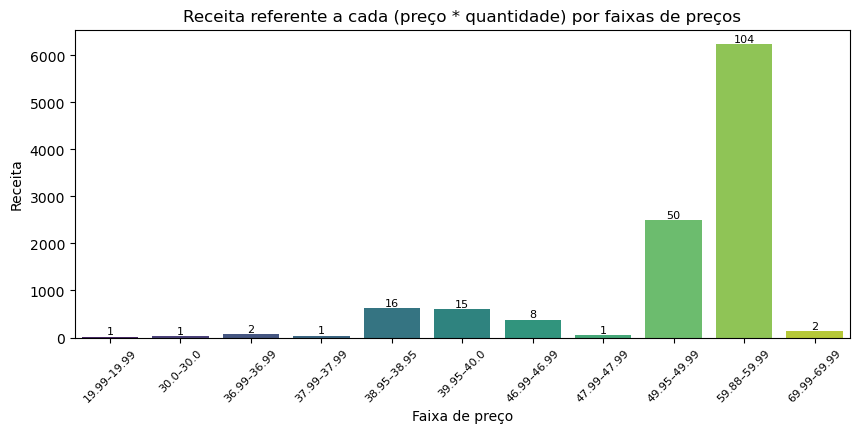

In [26]:
plt.figure(figsize=(10, 4))
ax = sns.barplot(x='faixa_preco', y='receita_total', data=df_bin, palette='viridis')
plt.xlabel('Faixa de preço')
plt.ylabel('Receita')
plt.xticks(rotation=45, fontsize=8)
plt.title('Receita referente a cada (preço * quantidade) por faixas de preços')

for i, (receita_total, quantidade_soma) in enumerate(zip(df_bin['receita_total'], df_bin['quantidade_soma'])):
    ax.text(i, receita_total + 5, str(quantidade_soma), ha='center', va='bottom', fontsize=8)  

plt.show()

In [27]:
# assumindo df com 'preco' e 'quantidade'
preco = df_bin['preco_medio'].values
quantidade = df_bin['quantidade_soma'].values

# curve_fit
p0 = [quantidade.max(), np.median(preco), np.std(preco)]
popt, pcov = curve_fit(gauss, preco, quantidade, p0=p0, maxfev=10000)
a_cf, mu_cf, sigma_cf = popt
se_cf = np.sqrt(np.diag(pcov))

# statsmodels (GenericLikelihoodModel)
class GaussModel(GenericLikelihoodModel):
    def nloglikeobs(self, params):
        a, mu, sigma = params
        yhat = gauss(preco, a, mu, sigma)
        resid = quantidade - yhat
        sigma_res = np.std(resid)
        return 0.5 * np.log(2*np.pi) + np.log(sigma_res) + 0.5*(resid/sigma_res)**2

mod = GaussModel(quantidade)
mod.endog_index = preco
res = mod.fit(start_params=p0, method="bfgs", disp=False, maxiter=10000)
a_sm, mu_sm, sigma_sm = res.params

# Elasticidades
df_bin['elasticidade_curvefit'] = elasticity_gauss(df_bin['preco_medio'], mu_cf, sigma_cf)
df_bin['elasticidade_statsmodels'] = elasticity_gauss(df_bin['preco_medio'], mu_sm, sigma_sm)

# Impressões rápidas
print("curve_fit params:", popt, "std err:", se_cf)
print(res.summary())

curve_fit params: [1133.95360677   55.28818322    2.12810773] std err: [2.99880174e+03 3.38533445e-01 1.02827419e+00]
                              GaussModel Results                              
Dep. Variable:                      y   Log-Likelihood:                -55.124
Model:                     GaussModel   AIC:                             122.2
Method:            Maximum Likelihood   BIC:                             124.6
Date:                Mon, 22 Sep 2025                                         
Time:                        19:04:26                                         
No. Observations:                  11                                         
Df Residuals:                       8                                         
Df Model:                           3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
par0         

In [29]:
df_bin

,grupo,preco_min,preco_max,preco_medio,quantidade_soma,receita_total,faixa_preco,elasticidade_curvefit,elasticidade_statsmodels
0,0,19.99,19.99,19.99,1,19.99,19.99–19.99,155.803759,7279.599883
1,1,30.00,30.00,30.00,1,30.00,30.0–30.0,167.514215,4313.530849
2,2,36.99,36.99,36.99,2,73.98,36.99–36.99,149.453155,-373.812433
3,3,37.99,37.99,37.99,1,37.99,37.99–37.99,145.105064,-1220.296758
4,4,38.95,38.95,38.95,16,623.20,38.95–38.95,140.515427,-2074.346556
5,5,39.95,40.00,39.98,15,599.59,39.95–40.0,135.138541,-3035.796513
6,6,46.99,46.99,46.99,8,375.92,46.99–46.99,86.099623,-10820.073689
7,7,47.99,47.99,47.99,1,47.99,47.99–47.99,77.335393,-12106.873127
8,8,49.95,49.99,49.97,50,2499.02,49.95–49.99,58.679368,-14784.637777
9,9,59.88,59.99,59.94,104,6235.01,59.88–59.99,-61.567586,-30891.119621


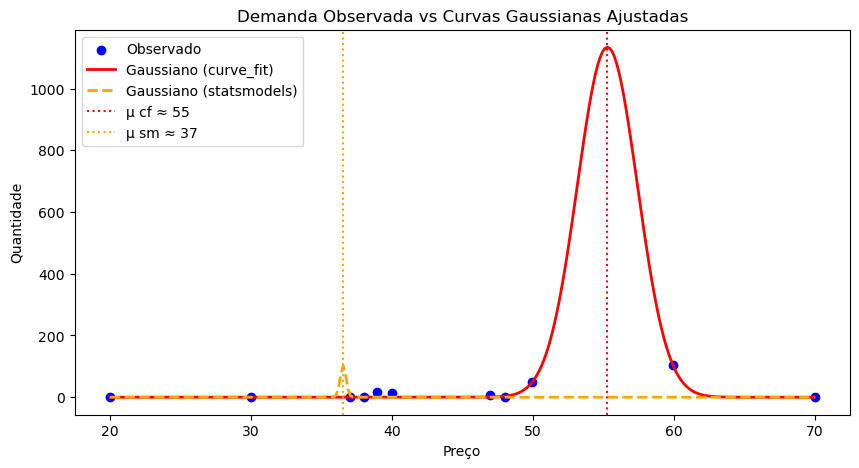

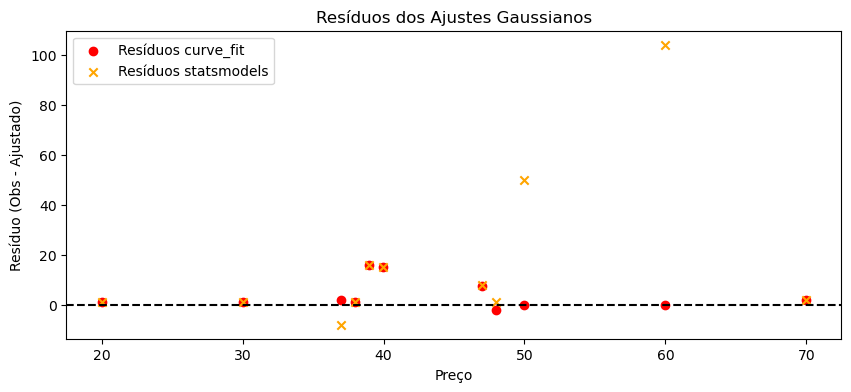

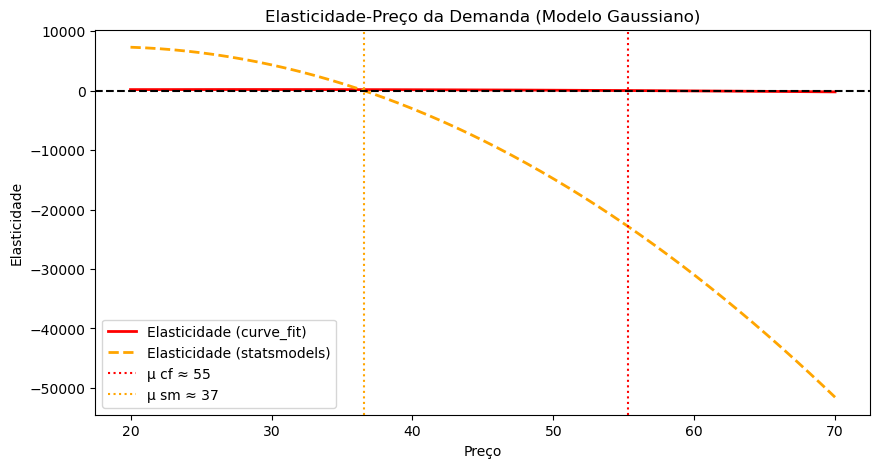

In [28]:
# Parâmetros estimados
a_cf, mu_cf, sigma_cf = popt  # do curve_fit
a_sm, mu_sm, sigma_sm = res.params  # do statsmodels

# Grid de preços para curvas suaves
preco_grid = np.linspace(df_bin['preco_medio'].min(), df_bin['preco_medio'].max(), 300)

# Previsões
q_pred_cf = gauss(preco_grid, a_cf, mu_cf, sigma_cf)
q_pred_sm = gauss(preco_grid, a_sm, mu_sm, sigma_sm)

# 1. Curva ajustada vs dados
plt.figure(figsize=(10,5))
plt.scatter(df_bin['preco_medio'], df_bin['quantidade_soma'], color="blue", label="Observado")
plt.plot(preco_grid, q_pred_cf, color="red", linewidth=2, label="Gaussiano (curve_fit)")
plt.plot(preco_grid, q_pred_sm, color="orange", linestyle="--", linewidth=2, label="Gaussiano (statsmodels)")
plt.axvline(mu_cf, color="red", linestyle=":", label=f"μ cf ≈ {mu_cf:.0f}")
plt.axvline(mu_sm, color="orange", linestyle=":", label=f"μ sm ≈ {mu_sm:.0f}")
plt.title("Demanda Observada vs Curvas Gaussianas Ajustadas")
plt.xlabel("Preço")
plt.ylabel("Quantidade")
plt.legend()
plt.show()

# 2. Resíduos
q_fit_cf = gauss(df_bin['preco_medio'], a_cf, mu_cf, sigma_cf)
q_fit_sm = gauss(df_bin['preco_medio'], a_sm, mu_sm, sigma_sm)
residuos_cf = df_bin['quantidade_soma'] - q_fit_cf
residuos_sm = df_bin['quantidade_soma'] - q_fit_sm

plt.figure(figsize=(10,4))
plt.axhline(0, color="black", linestyle="--")
plt.scatter(df_bin['preco_medio'], residuos_cf, color="red", label="Resíduos curve_fit")
plt.scatter(df_bin['preco_medio'], residuos_sm, color="orange", marker="x", label="Resíduos statsmodels")
plt.title("Resíduos dos Ajustes Gaussianos")
plt.xlabel("Preço")
plt.ylabel("Resíduo (Obs - Ajustado)")
plt.legend()
plt.show()

# 3. Elasticidade vs preço
elasticidade_cf = elasticity_gauss(preco_grid, mu_cf, sigma_cf)
elasticidade_sm = elasticity_gauss(preco_grid, mu_sm, sigma_sm)

plt.figure(figsize=(10,5))
plt.plot(preco_grid, elasticidade_cf, color="red", linewidth=2, label="Elasticidade (curve_fit)")
plt.plot(preco_grid, elasticidade_sm, color="orange", linestyle="--", linewidth=2, label="Elasticidade (statsmodels)")
plt.axhline(0, color="black", linestyle="--")
plt.axvline(mu_cf, color="red", linestyle=":", label=f"μ cf ≈ {mu_cf:.0f}")
plt.axvline(mu_sm, color="orange", linestyle=":", label=f"μ sm ≈ {mu_sm:.0f}")
plt.title("Elasticidade-Preço da Demanda (Modelo Gaussiano)")
plt.xlabel("Preço")
plt.ylabel("Elasticidade")
plt.legend()
plt.show()

In [ ]:
# o curve_fit conseguiu ajustar melhor a gaussiana aos dados que o statsmodels,
# mas, o cálculo da elasticidade ainda não está dentro de valores 'aceitáveis' ( E < 10)